In [3]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('/content/NCRB_Table_1A.1.csv')

# Basic check
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:")
print(df.columns)

Shape: (39, 8)

First 5 rows:
  Sl. No.           State/UT    2020    2021    2022  \
0       1     Andhra Pradesh  188997  179611  158547   
1       2  Arunachal Pradesh    2244    2626    2308   
2       3              Assam  111558  119883   59315   
3       4              Bihar  194698  186006  211079   
4       5       Chhattisgarh   65216   70519   73822   

   Mid-Year Projected Population (in Lakhs) (2022)  \
0                                            530.3   
1                                             15.5   
2                                            354.9   
3                                           1255.3   
4                                            299.5   

   Rate of Cognizable Crimes (IPC) (2022)  Chargesheeting Rate (2022)  
0                                   299.0                        86.5  
1                                   148.8                        47.2  
2                                   167.1                        32.6  
3                   

In [ ]:
# Check data info
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
print(df.describe())

Shape: (39, 8)

Missing values:
Sl. No.                                            0
State/UT                                           0
2020                                               0
2021                                               0
2022                                               0
Mid-Year Projected Population (in Lakhs) (2022)    0
Rate of Cognizable Crimes (IPC) (2022)             0
Chargesheeting Rate (2022)                         0
dtype: int64

Basic Statistics:
               2020          2021          2022  \
count  3.900000e+01  3.900000e+01  3.900000e+01   
mean   3.272582e+05  2.817969e+05  2.739522e+05   
std    9.083960e+05  7.682254e+05  7.453848e+05   
min    1.070000e+02  8.900000e+01  6.400000e+01   
25%    2.727000e+03  2.555000e+03  2.985000e+03   
50%    6.521600e+04  7.051900e+04  5.931500e+04   
75%    1.939885e+05  2.002790e+05  2.024960e+05   
max    4.254356e+06  3.663360e+06  3.561379e+06   

       Mid-Year Projected Population (in Lakhs) (202

/tmp/ipykernel_2518/4048405040.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='2022', y='State/UT', data=top10, palette='Reds_r')


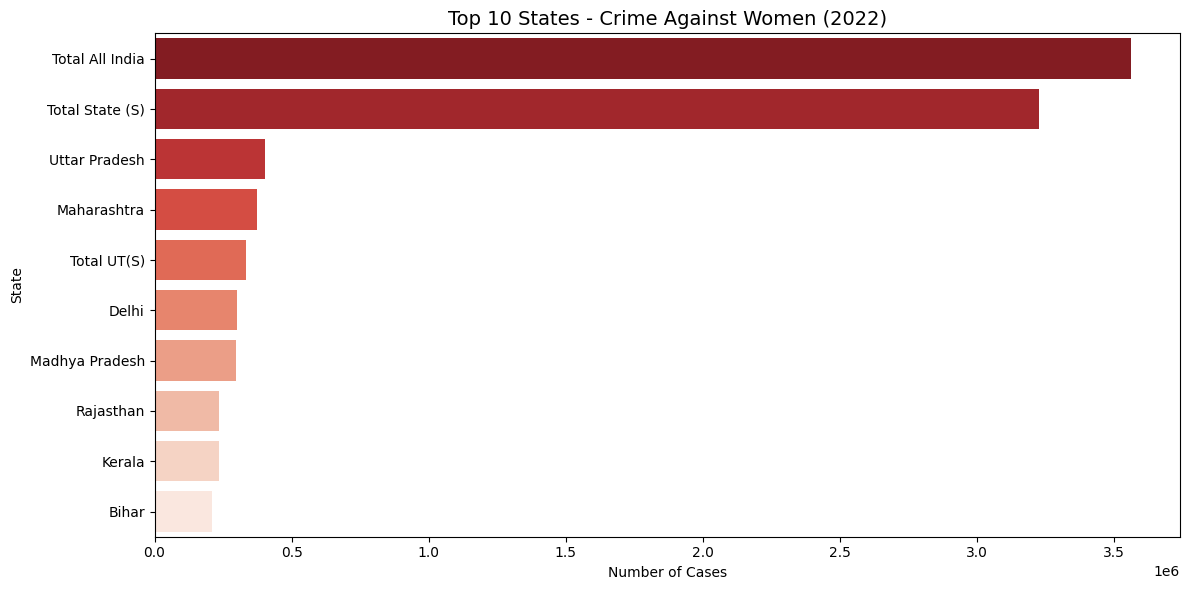

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 states with highest crime in 2022
top10 = df.nlargest(10, '2022')[['State/UT', '2022']]

plt.figure(figsize=(12, 6))
sns.barplot(x='2022', y='State/UT', data=top10, palette='Reds_r')
plt.title('Top 10 States - Crime Against Women (2022)', fontsize=14)
plt.xlabel('Number of Cases')
plt.ylabel('State')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2518/3983467502.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='2022', y='State/UT', data=top10, palette='Reds_r')


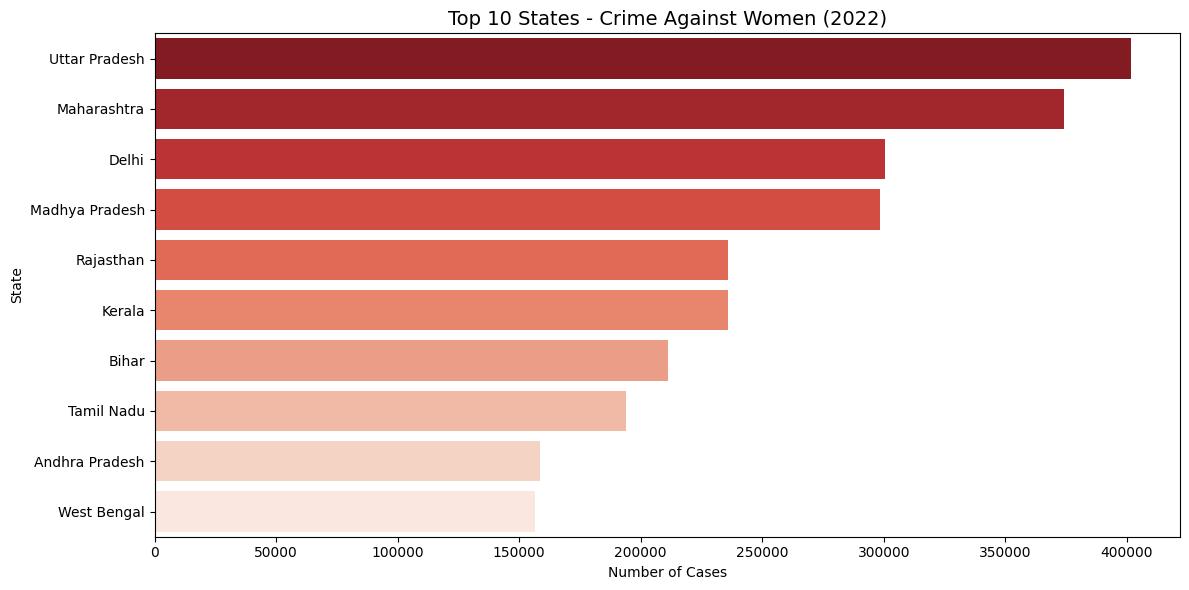

In [6]:
# Remove total rows - keep only actual states
df_states = df[~df['State/UT'].str.contains('Total')]

# Now plot again
top10 = df_states.nlargest(10, '2022')[['State/UT', '2022']]

plt.figure(figsize=(12, 6))
sns.barplot(x='2022', y='State/UT', data=top10, palette='Reds_r')
plt.title('Top 10 States - Crime Against Women (2022)', fontsize=14)
plt.xlabel('Number of Cases')
plt.ylabel('State')
plt.tight_layout()
plt.show()

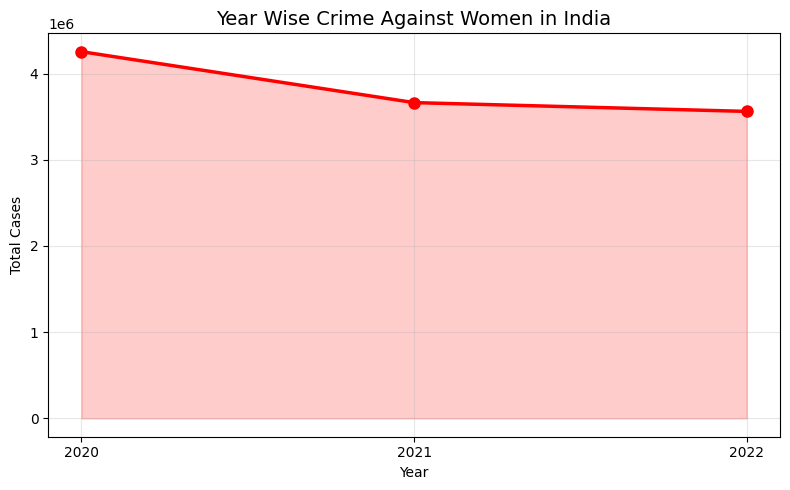

2020: 4,254,356 cases
2021: 3,663,360 cases
2022: 3,561,379 cases


In [7]:
# Year wise total crime trend
years = ['2020', '2021', '2022']
totals = df_states[years].sum()

plt.figure(figsize=(8, 5))
plt.plot(years, totals, marker='o', color='red',
         linewidth=2.5, markersize=8)
plt.fill_between(years, totals, alpha=0.2, color='red')
plt.title('Year Wise Crime Against Women in India', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total Cases')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print numbers
for year, total in zip(years, totals):
    print(f"{year}: {total:,} cases")

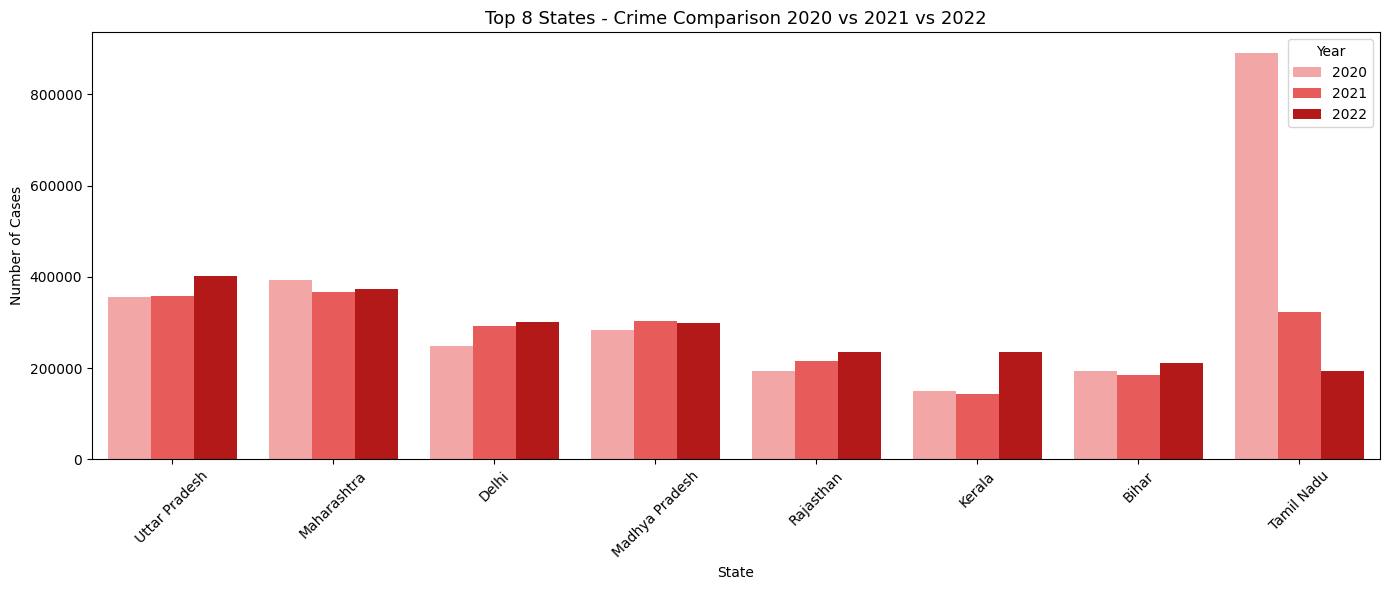

In [8]:
# State wise comparison - 2020, 2021, 2022
top8 = df_states.nlargest(8, '2022')[['State/UT', '2020', '2021', '2022']]

top8_melted = top8.melt(id_vars='State/UT',
                         var_name='Year',
                         value_name='Cases')

plt.figure(figsize=(14, 6))
sns.barplot(x='State/UT', y='Cases',
            hue='Year', data=top8_melted,
            palette=['#ff9999','#ff4444','#cc0000'])
plt.title('Top 8 States - Crime Comparison 2020 vs 2021 vs 2022',
          fontsize=13)
plt.xlabel('State')
plt.ylabel('Number of Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2518/2060155407.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_states['Crime_Rate_2022'] = (df_states['2022'] /
/tmp/ipykernel_2518/2060155407.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Crime_Rate_2022', y='State/UT',


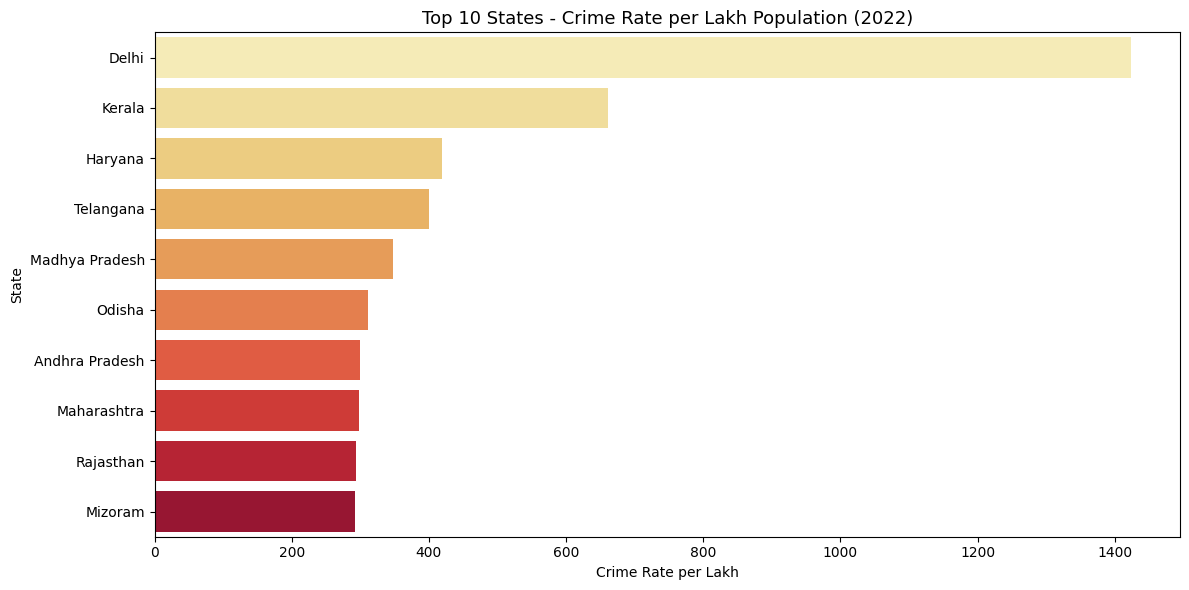

In [9]:
# Crime rate per lakh population
df_states['Crime_Rate_2022'] = (df_states['2022'] /
    df_states['Mid-Year Projected Population (in Lakhs) (2022)'])

# Top 10 by crime rate
top_rate = df_states.nlargest(10, 'Crime_Rate_2022')[
    ['State/UT', 'Crime_Rate_2022']]

plt.figure(figsize=(12, 6))
sns.barplot(x='Crime_Rate_2022', y='State/UT',
            data=top_rate, palette='YlOrRd')
plt.title('Top 10 States - Crime Rate per Lakh Population (2022)',
          fontsize=13)
plt.xlabel('Crime Rate per Lakh')
plt.ylabel('State')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2518/2744169748.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Predicted_2023', y='State/UT',


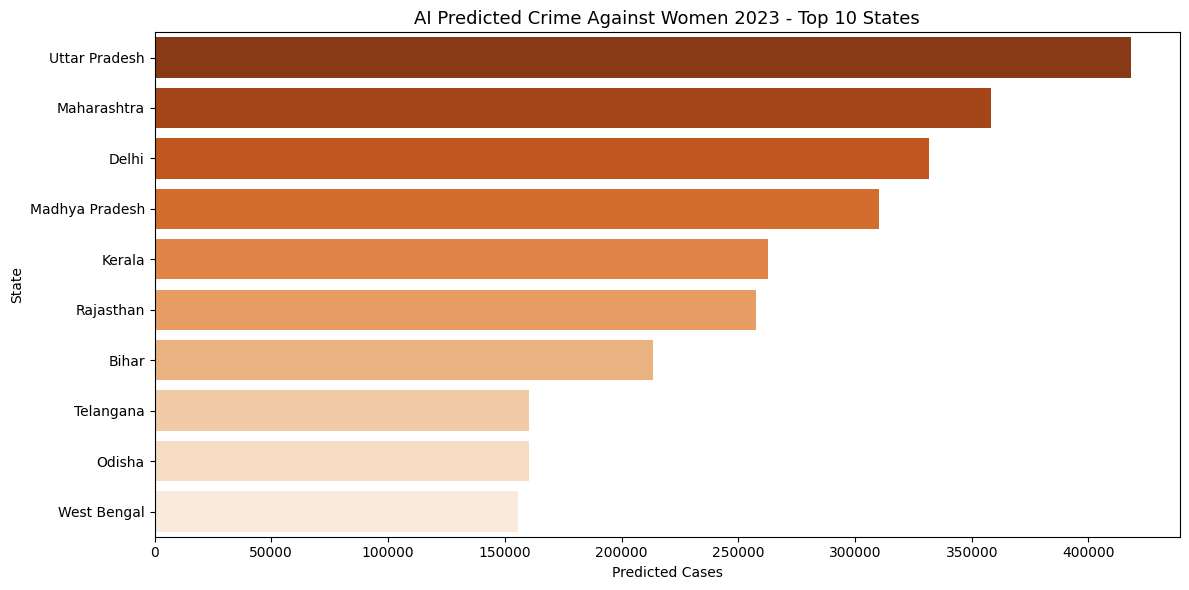


Top 5 Predicted States for 2023:
          State/UT  Predicted_2023
25   Uttar Pradesh          418277
13     Maharashtra          358445
31           Delhi          331745
12  Madhya Pradesh          310205
11          Kerala          262625


In [10]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Predict 2023 crime for each state
X = np.array([2020, 2021, 2022]).reshape(-1, 1)

predictions = []
for _, row in df_states.iterrows():
    y = np.array([row['2020'], row['2021'], row['2022']])
    model = LinearRegression()
    model.fit(X, y)
    pred_2023 = model.predict([[2023]])[0]
    predictions.append({
        'State/UT': row['State/UT'],
        'Predicted_2023': int(pred_2023)
    })

pred_df = pd.DataFrame(predictions)

# Top 10 predicted states for 2023
top_pred = pred_df.nlargest(10, 'Predicted_2023')

plt.figure(figsize=(12, 6))
sns.barplot(x='Predicted_2023', y='State/UT',
            data=top_pred, palette='Oranges_r')
plt.title('AI Predicted Crime Against Women 2023 - Top 10 States',
          fontsize=13)
plt.xlabel('Predicted Cases')
plt.ylabel('State')
plt.tight_layout()
plt.show()

print("\nTop 5 Predicted States for 2023:")
print(top_pred.head())

In [11]:
# Save all insights in one summary
print("=" * 50)
print("   WOMEN SAFETY ANALYTICS - KEY INSIGHTS")
print("=" * 50)

print("\n📊 DATASET INFO:")
print(f"   Total States/UTs analyzed: {len(df_states)}")
print(f"   Years covered: 2020, 2021, 2022")

print("\n🔴 HIGHEST CRIME STATES (2022):")
top5 = df_states.nlargest(5, '2022')[['State/UT', '2022']]
for _, row in top5.iterrows():
    print(f"   {row['State/UT']}: {row['2022']:,} cases")

print("\n📉 YEAR WISE TOTAL CRIMES:")
for year in ['2020', '2021', '2022']:
    print(f"   {year}: {df_states[year].sum():,} cases")

print("\n🤖 AI PREDICTED 2023 - TOP 3 HIGH RISK STATES:")
for _, row in top_pred.head(3).iterrows():
    print(f"   {row['State/UT']}: {row['Predicted_2023']:,} cases")

print("\n✅ Analysis Complete!")

   WOMEN SAFETY ANALYTICS - KEY INSIGHTS

📊 DATASET INFO:
   Total States/UTs analyzed: 36
   Years covered: 2020, 2021, 2022

🔴 HIGHEST CRIME STATES (2022):
   Uttar Pradesh: 401,787 cases
   Maharashtra: 374,038 cases
   Delhi: 300,429 cases
   Madhya Pradesh: 298,578 cases
   Rajasthan: 236,090 cases

📉 YEAR WISE TOTAL CRIMES:
   2020: 4,254,356 cases
   2021: 3,663,360 cases
   2022: 3,561,379 cases

🤖 AI PREDICTED 2023 - TOP 3 HIGH RISK STATES:
   Uttar Pradesh: 418,277 cases
   Maharashtra: 358,445 cases
   Delhi: 331,745 cases

✅ Analysis Complete!


/tmp/ipykernel_2518/2360170806.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='2026', y='State/UT',


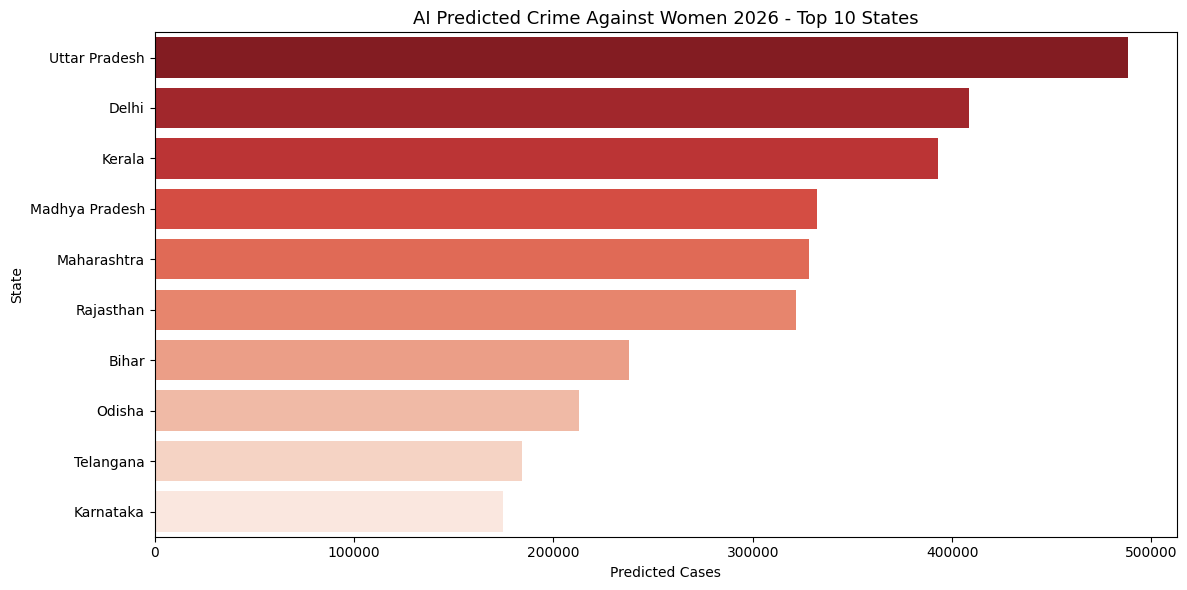


🤖 AI PREDICTED TOP 5 HIGH RISK STATES 2026:
   Uttar Pradesh: 488,293 cases
   Delhi: 408,600 cases
   Kerala: 392,764 cases
   Madhya Pradesh: 332,250 cases
   Maharashtra: 328,476 cases


In [12]:
# Predict 2023, 2024, 2025, 2026
X = np.array([2020, 2021, 2022]).reshape(-1, 1)
future_years = [2023, 2024, 2025, 2026]

future_predictions = []
for _, row in df_states.iterrows():
    y = np.array([row['2020'], row['2021'], row['2022']])
    model = LinearRegression()
    model.fit(X, y)

    preds = {}
    preds['State/UT'] = row['State/UT']
    for yr in future_years:
        pred = model.predict([[yr]])[0]
        preds[str(yr)] = max(0, int(pred))
    future_predictions.append(preds)

future_df = pd.DataFrame(future_predictions)

# Show top 10 states for 2026
top_2026 = future_df.nlargest(10, '2026')[['State/UT', '2023', '2024', '2025', '2026']]

plt.figure(figsize=(12, 6))
sns.barplot(x='2026', y='State/UT',
            data=top_2026, palette='Reds_r')
plt.title('AI Predicted Crime Against Women 2026 - Top 10 States',
          fontsize=13)
plt.xlabel('Predicted Cases')
plt.ylabel('State')
plt.tight_layout()
plt.show()

print("\n🤖 AI PREDICTED TOP 5 HIGH RISK STATES 2026:")
for _, row in top_2026.head(5).iterrows():
    print(f"   {row['State/UT']}: {row['2026']:,} cases")

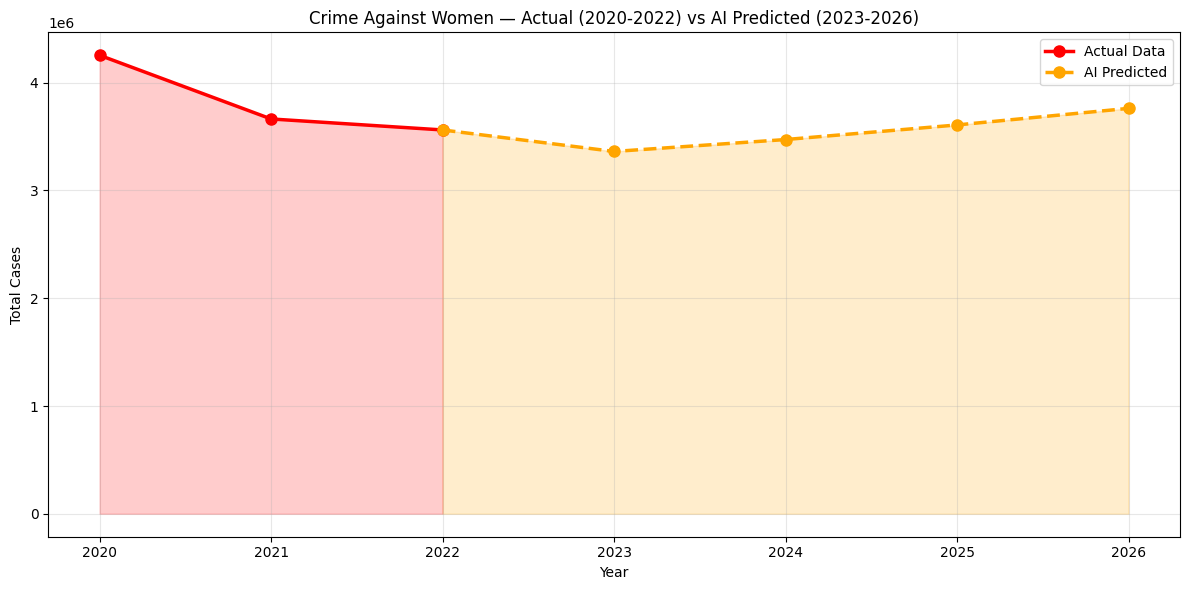

In [15]:
# Year wise prediction trend 2020 to 2026
all_years = ['2020', '2021', '2022', '2023', '2024', '2025', '2026']

actual = [df_states['2020'].sum(),
          df_states['2021'].sum(),
          df_states['2022'].sum()]

predicted = [future_df['2023'].sum(),
             future_df['2024'].sum(),
             future_df['2025'].sum(),
             future_df['2026'].sum()]

plt.figure(figsize=(12, 6))
# Actual data
plt.plot(['2020','2021','2022'], actual,
         marker='o', color='red',
         linewidth=2.5, markersize=8, label='Actual Data')

# Predicted data
plt.plot(['2022','2023','2024','2025','2026'],
         [actual[2]] + predicted,
         marker='o', color='orange',
         linewidth=2.5, markersize=8,
         linestyle='--', label='AI Predicted')

plt.fill_between(['2020','2021','2022'], actual,
                 alpha=0.2, color='red')
plt.fill_between(['2022','2023','2024','2025','2026'],
                 [actual[2]] + predicted,
                 alpha=0.2, color='orange')

plt.title('Crime Against Women — Actual (2020-2022) vs AI Predicted (2023-2026)',
          fontsize=12)
plt.xlabel('Year')
plt.ylabel('Total Cases')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()